# Naive Bayes Classification — Breast Cancer Dataset

## Step 1 — Load the dataset

In [1]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

## Step 2 — Create X and y

In [2]:
X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


## Step 3 — Check the target/classes

In [3]:
import numpy as np

print(data.target_names)
print(np.bincount(y))
print(np.bincount(y) / len(y))

['malignant' 'benign']
[212 357]
[0.37258348 0.62741652]


## Step 4 — Split the data

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


## Step 5 — Standardize the features

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6 — Create the Naive Bayes model

In [6]:
from sklearn.naive_bayes import GaussianNB

model_nb = GaussianNB()

## Step 7 — Train the model

In [7]:
model_nb.fit(X_train_scaled, y_train)

GaussianNB()

## Step 8 — Make predictions

In [8]:
y_pred_nb = model_nb.predict(X_test_scaled)

print(y_pred_nb)

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0
 0 1 1]


## Step 9 — Calculate accuracy

In [9]:
from sklearn.metrics import accuracy_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy:", accuracy_nb)
print("Accuracy (%):", accuracy_nb * 100)

Accuracy: 0.9298245614035088
Accuracy (%): 92.98245614035088


## Step 10 — Confusion matrix

In [10]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[38  4]
 [ 4 68]]


## Step 11 — Plot the confusion matrix with Matplotlib

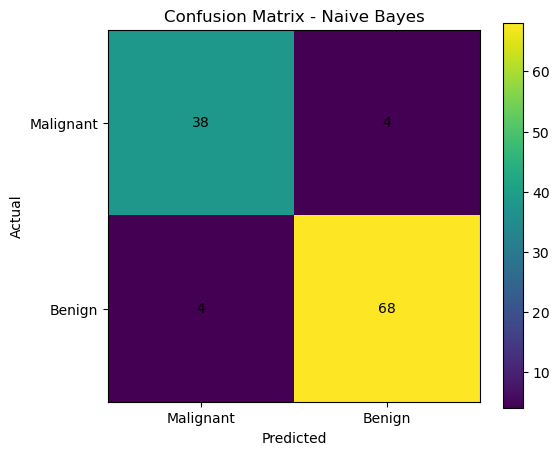

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm_nb)

plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_nb[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## Step 12 — Classification report

In [12]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.90      0.90      0.90        42
      Benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



## Step 13 — Get probabilities

In [13]:
y_prob_nb = model_nb.predict_proba(X_test_scaled)

print(y_prob_nb[:5])

[[1.00000000e+000 2.17514008e-098]
 [8.00338902e-020 1.00000000e+000]
 [9.99999999e-001 8.73714788e-010]
 [9.84228575e-002 9.01577143e-001]
 [1.00000000e+000 7.24807703e-149]]


## Step 14 — Separate malignant and benign probabilities

In [14]:
malignant_prob_nb = y_prob_nb[:, 0]
benign_prob_nb = y_prob_nb[:, 1]

print("Malignant probabilities:")
print(malignant_prob_nb[:10])

print("Benign probabilities:")
print(benign_prob_nb[:10])

Malignant probabilities:
[1.00000000e+00 8.00338902e-20 9.99999999e-01 9.84228575e-02
 1.00000000e+00 4.76920840e-14 6.09274671e-14 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
Benign probabilities:
[2.17514008e-098 1.00000000e+000 8.73714788e-010 9.01577143e-001
 7.24807703e-149 1.00000000e+000 1.00000000e+000 9.35294440e-059
 2.14813639e-035 1.54379851e-126]


## Step 15 — Create a results table

In [15]:
import pandas as pd

results_nb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_nb,
    "Malignant_Probability": y_prob_nb[:, 0],
    "Benign_Probability": y_prob_nb[:, 1]
})

print(results_nb.head(10))

   Actual  Predicted  Malignant_Probability  Benign_Probability
0       0          0           1.000000e+00        2.175140e-98
1       1          1           8.003389e-20        1.000000e+00
2       0          0           1.000000e+00        8.737148e-10
3       1          1           9.842286e-02        9.015771e-01
4       0          0           1.000000e+00       7.248077e-149
5       1          1           4.769208e-14        1.000000e+00
6       1          1           6.092747e-14        1.000000e+00
7       0          0           1.000000e+00        9.352944e-59
8       0          0           1.000000e+00        2.148136e-35
9       0          0           1.000000e+00       1.543799e-126


## Step 16 — Check probability sums

In [16]:
print(y_prob_nb[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


## Step 17 — Visualize Naive Bayes probabilities

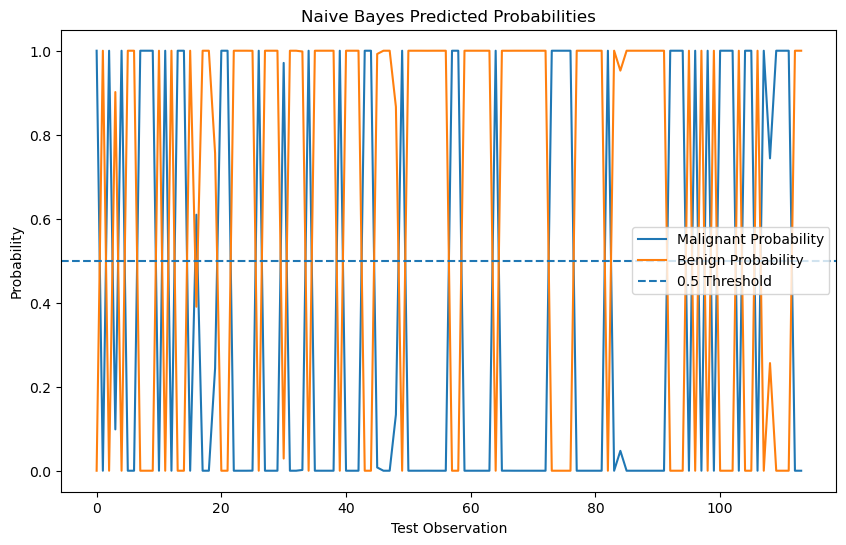

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(range(len(y_prob_nb)), malignant_prob_nb, label="Malignant Probability")
plt.plot(range(len(y_prob_nb)), benign_prob_nb, label="Benign Probability")

plt.axhline(y=0.5, linestyle="--", label="0.5 Threshold")

plt.xlabel("Test Observation")
plt.ylabel("Probability")
plt.title("Naive Bayes Predicted Probabilities")
plt.legend()

plt.show()

## Step 18 — Compare actual vs predicted

In [18]:
comparison_nb = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_nb
})

print(comparison_nb)

     Actual  Predicted
0         0          0
1         1          1
2         0          0
3         1          1
4         0          0
..      ...        ...
109       0          0
110       1          0
111       0          0
112       1          1
113       1          1

[114 rows x 2 columns]


## Step 19 — Count correct and incorrect predictions

In [19]:
correct_nb = (y_test == y_pred_nb).sum()
incorrect_nb = (y_test != y_pred_nb).sum()

print("Correct predictions:", correct_nb)
print("Incorrect predictions:", incorrect_nb)

Correct predictions: 106
Incorrect predictions: 8


## Step 20 — Calculate precision, recall, and F1-score

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-score:", f1_nb)

Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1-score: 0.9444444444444444


## Step 21 — Calculate malignant class metrics

In [21]:
precision_nb = precision_score(y_test, y_pred_nb, pos_label=0)
recall_nb = recall_score(y_test, y_pred_nb, pos_label=0)
f1_nb = f1_score(y_test, y_pred_nb, pos_label=0)

print("Malignant Precision:", precision_nb)
print("Malignant Recall:", recall_nb)
print("Malignant F1-score:", f1_nb)

Malignant Precision: 0.9047619047619048
Malignant Recall: 0.9047619047619048
Malignant F1-score: 0.9047619047619048


In [23]:
## FEATURE IMPRTANCE
import numpy as np
import pandas as pd

# Difference between class means
mean_diff = (
    model_nb.theta_[1] - model_nb.theta_[0]
)

# Average variance of the two classes
avg_variance = (
    model_nb.var_[1] + model_nb.var_[0]
) / 2

# Feature importance
feature_importance_nb = np.abs(mean_diff) / np.sqrt(avg_variance)

# Create DataFrame
feature_importance_nb = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": feature_importance_nb
})

# Sort from highest to lowest
feature_importance_nb = feature_importance_nb.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_nb)

                    Feature  Importance
27     worst concave points    2.632152
22          worst perimeter    2.384229
7       mean concave points    2.348434
20             worst radius    2.332499
2            mean perimeter    2.143775
0               mean radius    2.069847
23               worst area    2.002954
3                 mean area    1.892892
6            mean concavity    1.860767
26          worst concavity    1.791108
5          mean compactness    1.494638
25        worst compactness    1.439864
10             radius error    1.266134
13               area error    1.241396
12          perimeter error    1.216374
21            worst texture    1.044606
24         worst smoothness    0.973868
17     concave points error    0.951292
1              mean texture    0.931658
28           worst symmetry    0.918578
4           mean smoothness    0.880221
8             mean symmetry    0.778444
29  worst fractal dimension    0.674203
15        compactness error    0.619485
